In [1]:
import numpy as np 
import pandas as pd
import operator
import os
import chart_studio.tools as tls

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.backend_bases import RendererBase
from scipy import signal
from scipy.io import wavfile

import os
import numpy as np

from PIL import Image

from scipy.fftpack import fft
import librosa
import librosa.display

import plotly as py
tls.set_credentials_file(username='iam4tart',api_key='Docq9bPOpIqBxnDmPIxJ')

import chart_studio.plotly as py
import plotly.graph_objs as go

import cufflinks as cf
import IPython.display as ipd


/var/folders/bq/chj86vfj3c7f11203j8dzrtm0000gn/T/ipykernel_2153/883414657.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/Users/pabitraghosh/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:34: NotOpenSSLWarning: urllib3 v2.0 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
def get_files_with_features(path):
    data_ = []
    count = {}
    files = os.listdir(path)
    for file in files:
        labels = file.split("-")[:3]
        if len(labels) < 3:
            continue 
        data = {
            "keyword": labels[0],
            "stress": labels[2],
            "environment": labels[1],
            "path": os.path.join(path, file)
        }
        for label in labels:
            if label not in count.keys():
                count[label] = 1
            else:
                count[label] += 1

        data_.append(data)

    if data_:
        df = pd.DataFrame(data_)
    else:
        df = pd.DataFrame(columns=['keyword', 'stress', 'environment', 'path'])
    return data_, count, df

# Example usage
path = '/Users/pabitraghosh/Arya/EmoMFCC'
dataset_with_features, count, df_with_features = get_files_with_features(path)
print(df_with_features.head())

   keyword stress environment  \
0     help   calm        safe   
1       go  happy        safe   
2       no  happy        safe   
3  unknown   calm        safe   
4  unknown   calm        safe   

                                                path  
0  /Users/pabitraghosh/Arya/EmoMFCC/help-safe-cal...  
1  /Users/pabitraghosh/Arya/EmoMFCC/go-safe-happy...  
2  /Users/pabitraghosh/Arya/EmoMFCC/no-safe-happy...  
3  /Users/pabitraghosh/Arya/EmoMFCC/unknown-safe-...  
4  /Users/pabitraghosh/Arya/EmoMFCC/unknown-safe-...  


In [3]:
df_with_features.count()

keyword        15555
stress         15555
environment    15555
path           15555
dtype: int64

In [4]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [5]:
images = []
labels = []

for index, row in df_with_features.iterrows():
    image = cv2.imread(row['path'])
    image = cv2.resize(image, (64, 64))  # Resize images to a common size
    images.append(image)
    labels.append(row['stress'])

images = np.array(images)
labels = np.array(labels)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [7]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


In [8]:
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_test are your label arrays

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit and transform the training labels (y_train)
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform the test labels (y_test) using the fitted encoder
y_test_encoded = label_encoder.transform(y_test)


In [9]:
num_classes = df_with_features['stress'].nunique()
print(num_classes)

5


In [13]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

# Create a Sequential model
model4 = Sequential()

# Add layers
model4.add(Conv2D(45, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model4.add(AveragePooling2D(pool_size=(2, 2))) # Average pooling layer with default parameters
model4.add(Conv2D(30, (3, 3), activation='relu'))
model4.add(Conv2D(45, (3, 3), activation='relu'))
model4.add(Conv2D(33, (3, 3), activation='relu'))
model4.add(Conv2D(45, (3, 3), activation='relu'))
model4.add(Conv2D(35, (3, 3), activation='relu'))
model4.add(Conv2D(45, (3, 3), activation='relu'))
model4.add(AveragePooling2D(pool_size=(2, 2))) # Average pooling layer with default parameters
model4.add(Flatten())
model4.add(Dense(12, activation='relu'))
model4.add(Dense(5, activation='softmax'))  # Assuming there are 5 output classes (change if necessary)

# Print model summary
model4.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 62, 62, 45)     │         1,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 31, 31, 45)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 29, 29, 30)     │        12,180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 27, 27, 45)     │        12,195 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 25, 25, 33)     │        13,398 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 23, 23, 45)     │        13,410 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 21, 21, 35)     │        14,210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 19, 19, 45)     │        14,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 9, 9, 45)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3645)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │        43,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,690 (487.07 KB)

 Trainable params: 124,690 (487.07 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Compile the model
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Assuming X_train, X_test, y_train_encoded, y_test_encoded are already prepared

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=6, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model using X_train and y_train_encoded
history = model4.fit(X_train, y_train_encoded, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model using X_test and y_test_encoded
test_loss, test_acc = model4.evaluate(X_test, y_test_encoded)
print(f'Test accuracy: {test_acc}')


Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.5303 - loss: 1.4067 - val_accuracy: 0.6241 - val_loss: 1.1751 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 28s 80ms/step - accuracy: 0.6430 - loss: 1.1069 - val_accuracy: 0.6651 - val_loss: 0.9984 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 26s 75ms/step - accuracy: 0.6741 - loss: 0.9805 - val_accuracy: 0.6643 - val_loss: 0.9547 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.6873 - loss: 0.8902 - val_accuracy: 0.6972 - val_loss: 0.8915 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.7106 - loss: 0.8239 - val_accuracy: 0.6900 - val_loss: 0.8351 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.7131 - loss: 0.7968 - val_accuracy: 0.7068 - val_loss: 0.8256 - learning_rate: 0.0010
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 29s 82ms/step - accuracy: 0.7

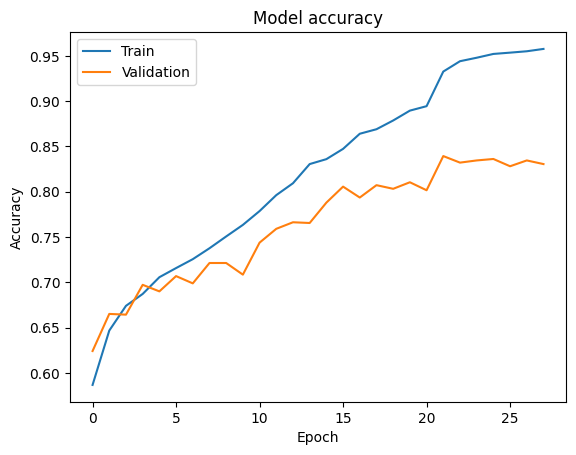

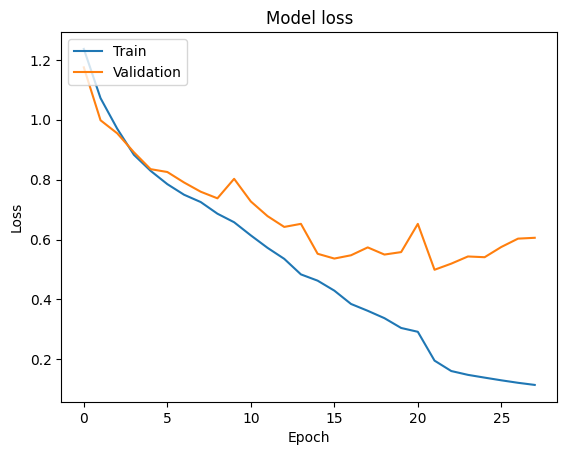

In [15]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

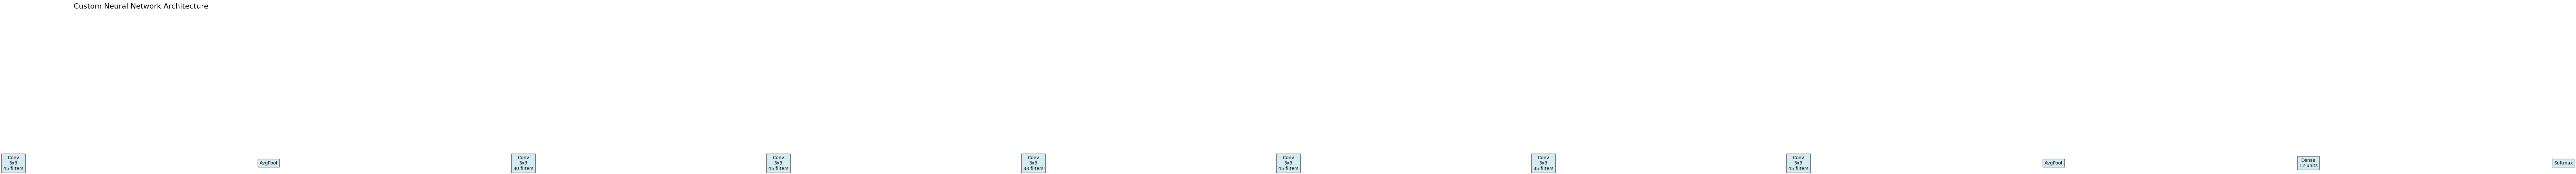

In [16]:
import matplotlib.pyplot as plt

# Define the layers and parameters
layers = [
    ("Conv", (3, 3), 45),
    ("AvgPool", None, None),
    ("Conv", (3, 3), 30),
    ("Conv", (3, 3), 45),
    ("Conv", (3, 3), 33),
    ("Conv", (3, 3), 45),
    ("Conv", (3, 3), 35),
    ("Conv", (3, 3), 45),
    ("AvgPool", None, None),
    ("Dense", None, 12),
    ("Softmax", None, None)
]

# Create the figure and axis objects
fig, ax = plt.subplots(figsize=(10, 6))

# Set title and axis properties
ax.set_title("Custom Neural Network Architecture", fontsize=16)
ax.axis('off')

# Plot each layer
x, y = 0, 0
for layer_type, kernel_size, num_filters in layers:
    if layer_type == "Conv":
        ax.text(x, y, f"Conv\n{kernel_size[0]}x{kernel_size[1]}\n{num_filters} filters", ha='center', va='center', fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.5))
    elif layer_type == "AvgPool":
        ax.text(x, y, "AvgPool", ha='center', va='center', fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.5))
    elif layer_type == "Dense":
        ax.text(x, y, f"Dense\n{num_filters} units", ha='center', va='center', fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.5))
    elif layer_type == "Softmax":
        ax.text(x, y, "Softmax", ha='center', va='center', fontsize=10, bbox=dict(facecolor='lightblue', alpha=0.5))
    x += 1

# Remove axes
plt.axis('off')
plt.tight_layout()

# Show the plot
plt.show()
